In [1]:
import sqlite3
import pandas as pd
import numpy as np
import os
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "gh-masterthesis-jasmine-29e28ba279bc.json"
from google.cloud import bigquery

# Create BigQuery client
client = bigquery.Client()
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
oss_interact = pd.read_parquet("oss_interact_clusterk47_0621.parquet")

In [3]:
list(oss_interact.columns)

['user',
 'project',
 'developer_id',
 'project_id',
 'interaction_type',
 'interaction_time',
 'project_owner_id',
 'project_language',
 'description',
 'country_code',
 'location',
 'company',
 'user_idx',
 'item_idx',
 'country_idx',
 'language_idx',
 'location_idx',
 'company_idx',
 'profile_similarity_score_1',
 'interaction_rating',
 'technical_ability',
 'num_members',
 'social_tie_score',
 'social_tie_score_norm',
 'cluster_allfeature',
 'K_mean_cluster_47']

In [9]:
language = pd.read_csv('Bigquery_language.csv')
country = pd.read_csv('country.csv')
company = pd.read_csv('Company.csv')
company

,company,company_count
0,Google,1082616
1,Red Hat,996357
2,Microsoft,592618
3,Mozilla,497321
4,"netdata, Inc.",369469
...,...,...
842,Alipay Co.,10027
843,@cypress-io,10022
844,@banzaicloud,10020
845,Splunk,10007


In [24]:
country_df = oss_interact['project_language'].value_counts().reset_index()
country_df.columns = ['country_code', 'count']
country_df

,country_code,count
0,JavaScript,119202
1,Python,60691
2,Ruby,57370
3,Java,38227
4,PHP,38120
5,C,14888
6,C++,14134
7,C#,7368


In [11]:
country = oss_interact.groupby('country_code')['interaction_weight'].sum().reset_index(name='country_count')

KeyError: 'Column not found: interaction_weight'

C:\Users\user\AppData\Local\Temp\ipykernel_69940\2630683048.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=country_df, x="country_code", y="count", palette="viridis")
C:\Users\user\AppData\Local\Temp\ipykernel_69940\2630683048.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Location", loc='upper right')


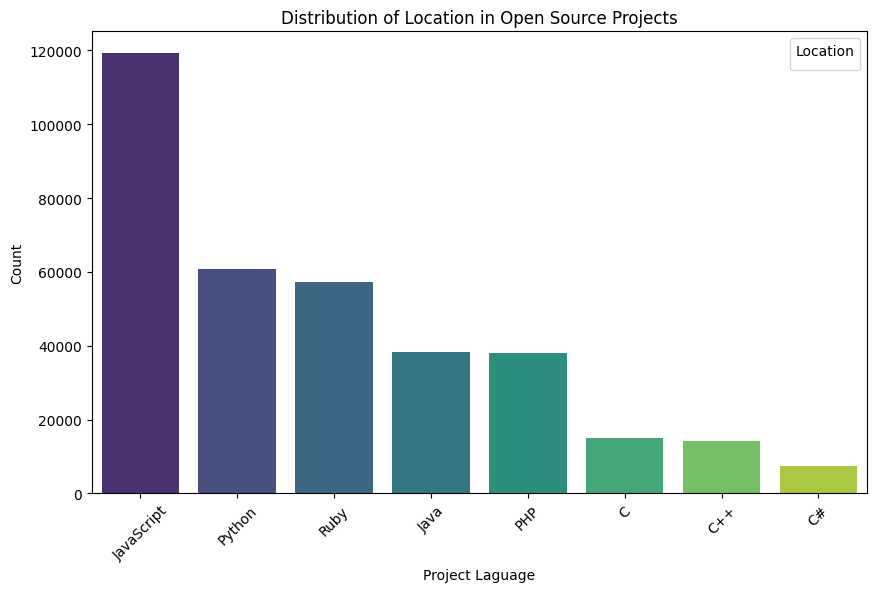

In [27]:
filtered = country_df['count']
#['project_language'] = language['project_language'].astype('category')
plt.figure(figsize=(10, 6))

# Creating the histogram with only the filtered languages
sns.barplot(data=country_df, x="country_code", y="count", palette="viridis")

plt.xlabel("Project Laguage")
plt.xticks(rotation=45)
plt.ylabel("Count")
plt.title("Distribution of Location in Open Source Projects")
plt.legend(title="Location", loc='upper right')

plt.show()


C:\Users\user\AppData\Local\Temp\ipykernel_44264\4020234294.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=filtered_oss_com, x="company", y="company_count", palette="viridis")
C:\Users\user\AppData\Local\Temp\ipykernel_44264\4020234294.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Company")


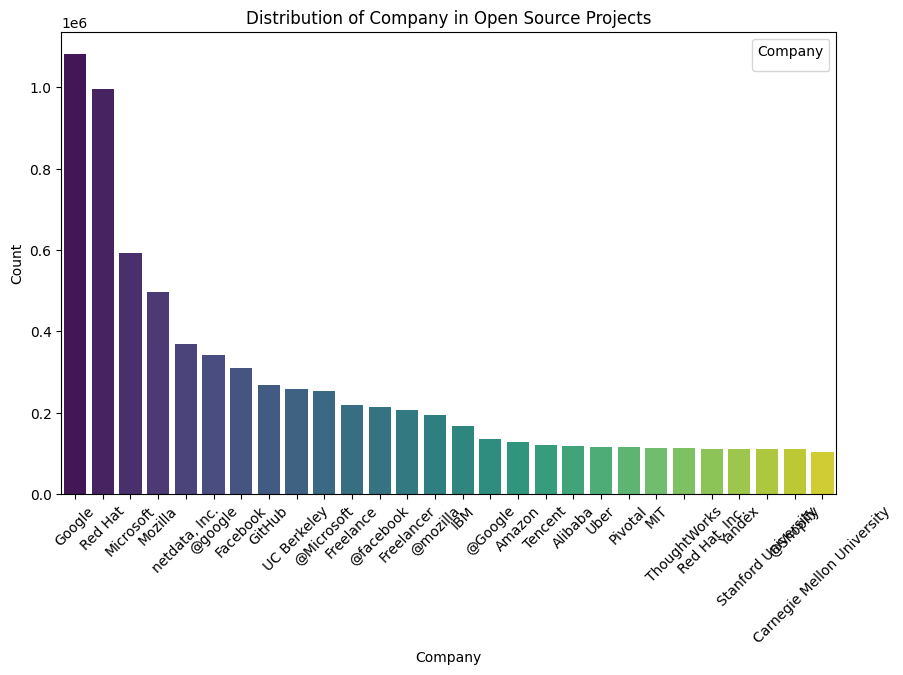

In [ ]:
filtered_oss_com = company[company['company_count'] > 100000]
#['project_language'] = language['project_language'].astype('category')
plt.figure(figsize=(10, 6))

# Creating the histogram with only the filtered languages
sns.barplot(data=filtered_oss_com, x="country_code", y="count", palette="viridis")

plt.xlabel("Company")
plt.xticks(rotation=45)
plt.ylabel("Count")
plt.title("Distribution of Company in Open Source Projects")
plt.legend(title="Company")

plt.show()


In [ ]:
filtered_oss_c = country[country['country_count'] > 500000]
#['project_language'] = language['project_language'].astype('category')
plt.figure(figsize=(10, 6))

# Creating the histogram with only the filtered languages
sns.barplot(data=filtered_oss_c, x="country_code", y="country_count", palette="viridis")

plt.xlabel("Country")
plt.xticks(rotation=45)
plt.ylabel("Count")
plt.title("Distribution of Country in Open Source Projects")
plt.legend(title="Country")

plt.show()


C:\Users\user\AppData\Local\Temp\ipykernel_44264\2469921087.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=interaction, y=interact_count, palette="viridis")


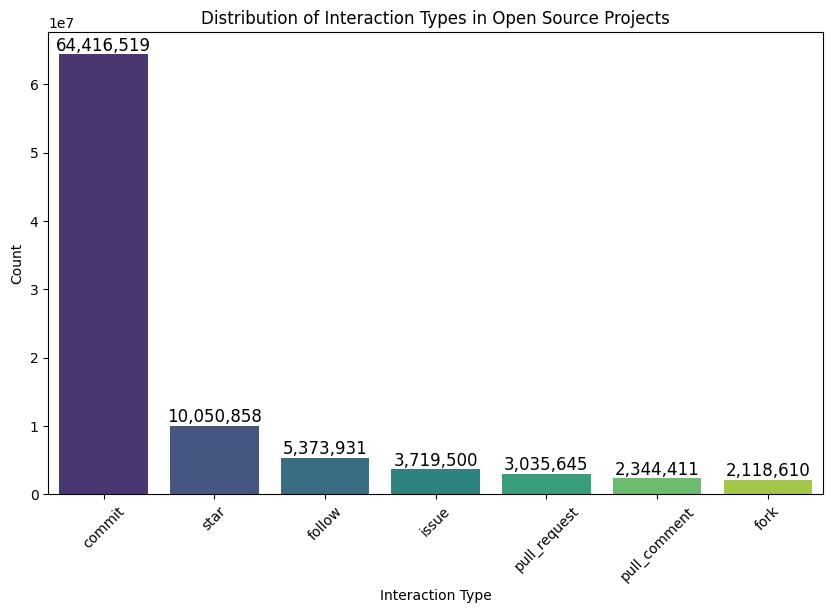

In [30]:


interaction = ["commit", "star", "follow", "issue", "pull_request", "pull_comment", "fork"]
interact_count = [64416519, 10050858, 5373931, 3719500, 3035645, 2344411, 2118610]

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=interaction, y=interact_count, palette="viridis")

# Adding text labels to each bar
for i, count in enumerate(interact_count):
    ax.text(i, count + 500000, f"{count:,}", ha='center', fontsize=12, color='black')

plt.xlabel("Interaction Type")
plt.xticks(rotation=45)
plt.ylabel("Count")
plt.title("Distribution of Interaction Types in Open Source Projects")

plt.show()


C:\Users\user\AppData\Local\Temp\ipykernel_179176\4038499923.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=interaction, y=interact_count, palette="viridis")


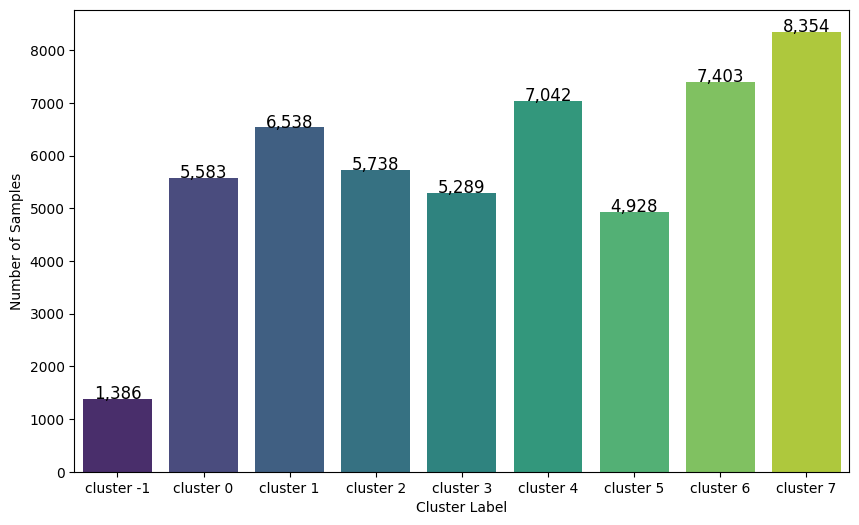

In [3]:


interaction = ["cluster -1", "cluster 0", "cluster 1", "cluster 2", "cluster 3", "cluster 4", "cluster 5", "cluster 6", "cluster 7"]  
interact_count = [1386, 5583,6538,5738,5289, 7042,4928, 7403, 8354]

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=interaction, y=interact_count, palette="viridis")

# Adding text labels to each bar
for i, count in enumerate(interact_count):
     ax.text(i, count, f"{count:,}", ha='center', fontsize=12, color='black')

plt.xlabel("Cluster Label")
# plt.xticks(rotation=45)
plt.ylabel("Number of Samples")
# plt.title("Distribution of Interaction Types in Open Source Projects")

plt.show()
